In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path ="/content/drive/MyDrive/consumer_classification_dataset (1).csv"
df = pd.read_csv(file_path)
df.head()

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1


In [ ]:
df.shape

(1500, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1425 non-null   float64
 1   Income            1425 non-null   float64
 2   Gender            1425 non-null   object 
 3   Marital_Status    1500 non-null   object 
 4   Credit_Score      1425 non-null   float64
 5   Num_Purchases     1500 non-null   int64  
 6   Membership_Years  1500 non-null   int64  
 7   Device_Used       1500 non-null   object 
 8   Churn             1500 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 105.6+ KB


In [ ]:
df.isnull().sum()

,0
Age,75
Income,75
Gender,75
Marital_Status,0
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Income'] = df['Income'].fillna(df['Income'].mean())
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df.isnull().sum()

,0
Age,0
Income,0
Gender,0
Marital_Status,0
Credit_Score,0
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


In [ ]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
0    757
1    743
Name: count, dtype: int64


/tmp/ipython-input-284288203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=df,palette=colors);


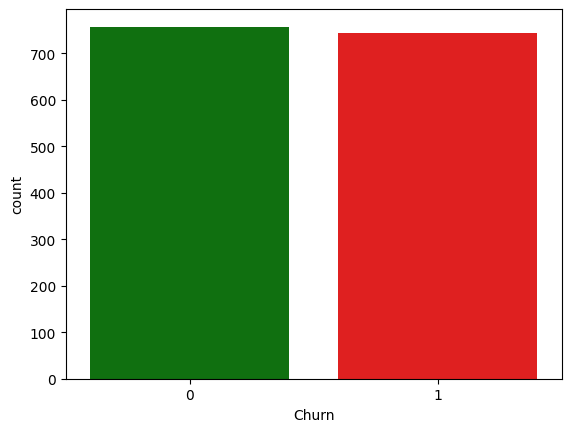

In [ ]:
colors = {"0": "green", "1": "red"}
sns.countplot(x='Churn',data=df,palette=colors);

In [ ]:
X=df.drop

In [ ]:
numerical_data = df.select_dtypes(include='number')

numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 6 numerical features: 

['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years', 'Churn']


In [ ]:
categoricalcategoricalcategorical_data=df.select_dtypes(include= 'object')

categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorial features:', '\n')
print(categorical_features)

There are 3 categorial features: 

['Gender', 'Marital_Status', 'Device_Used']


In [ ]:
numerical_data.describe()

,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Churn
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,43.750175,50446.150664,648.786794,5.078667,7.388667,0.495333
std,14.645399,14932.290074,67.820620,2.260653,3.974603,0.500145
min,18.000000,-826.421240,390.384237,0.000000,1.000000,0.000000
25%,32.000000,41145.108055,605.581215,3.000000,4.000000,0.000000
50%,43.750175,50446.150664,648.786794,5.000000,7.000000,0.000000
75%,55.000000,60115.496376,691.324232,6.000000,11.000000,1.000000
max,69.000000,98819.709397,906.039126,16.000000,14.000000,1.000000


In [ ]:
categorical_data.describe()

,Gender,Marital_Status,Device_Used
count,1500,1500,1500
unique,3,3,3
top,Other,Divorced,Desktop
freq,561,522,528


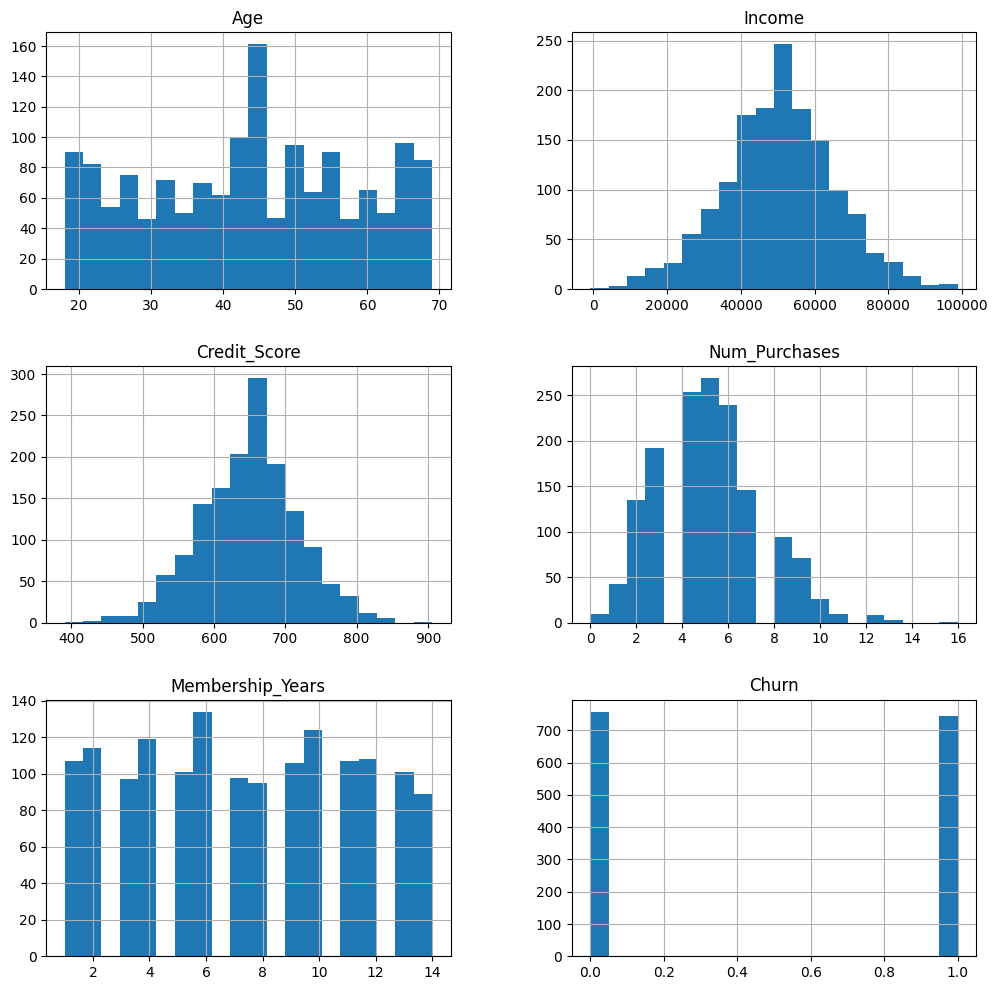

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

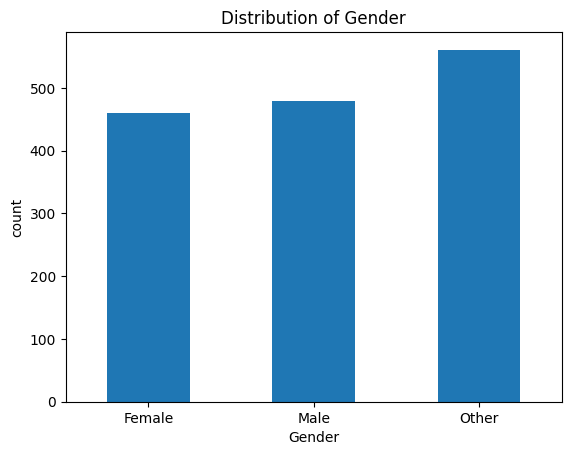

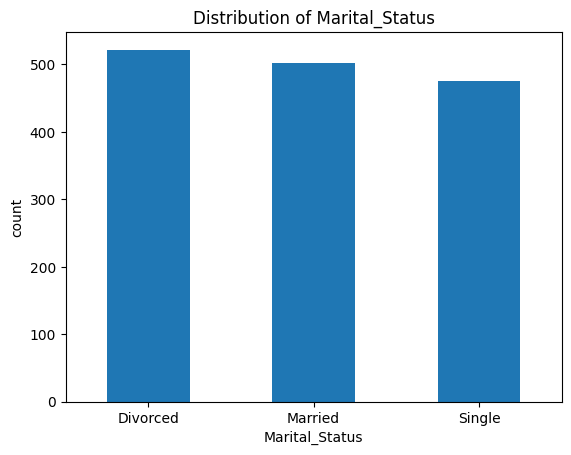

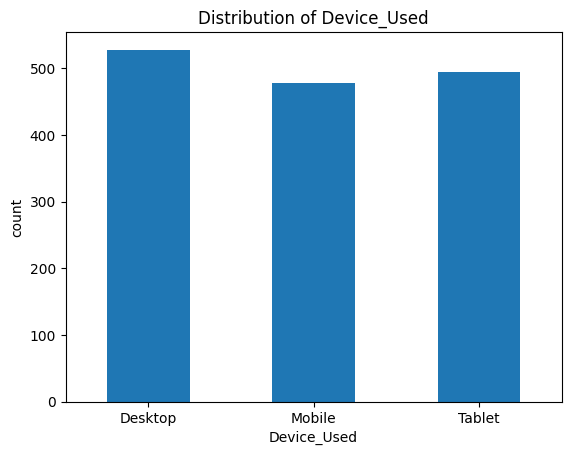

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

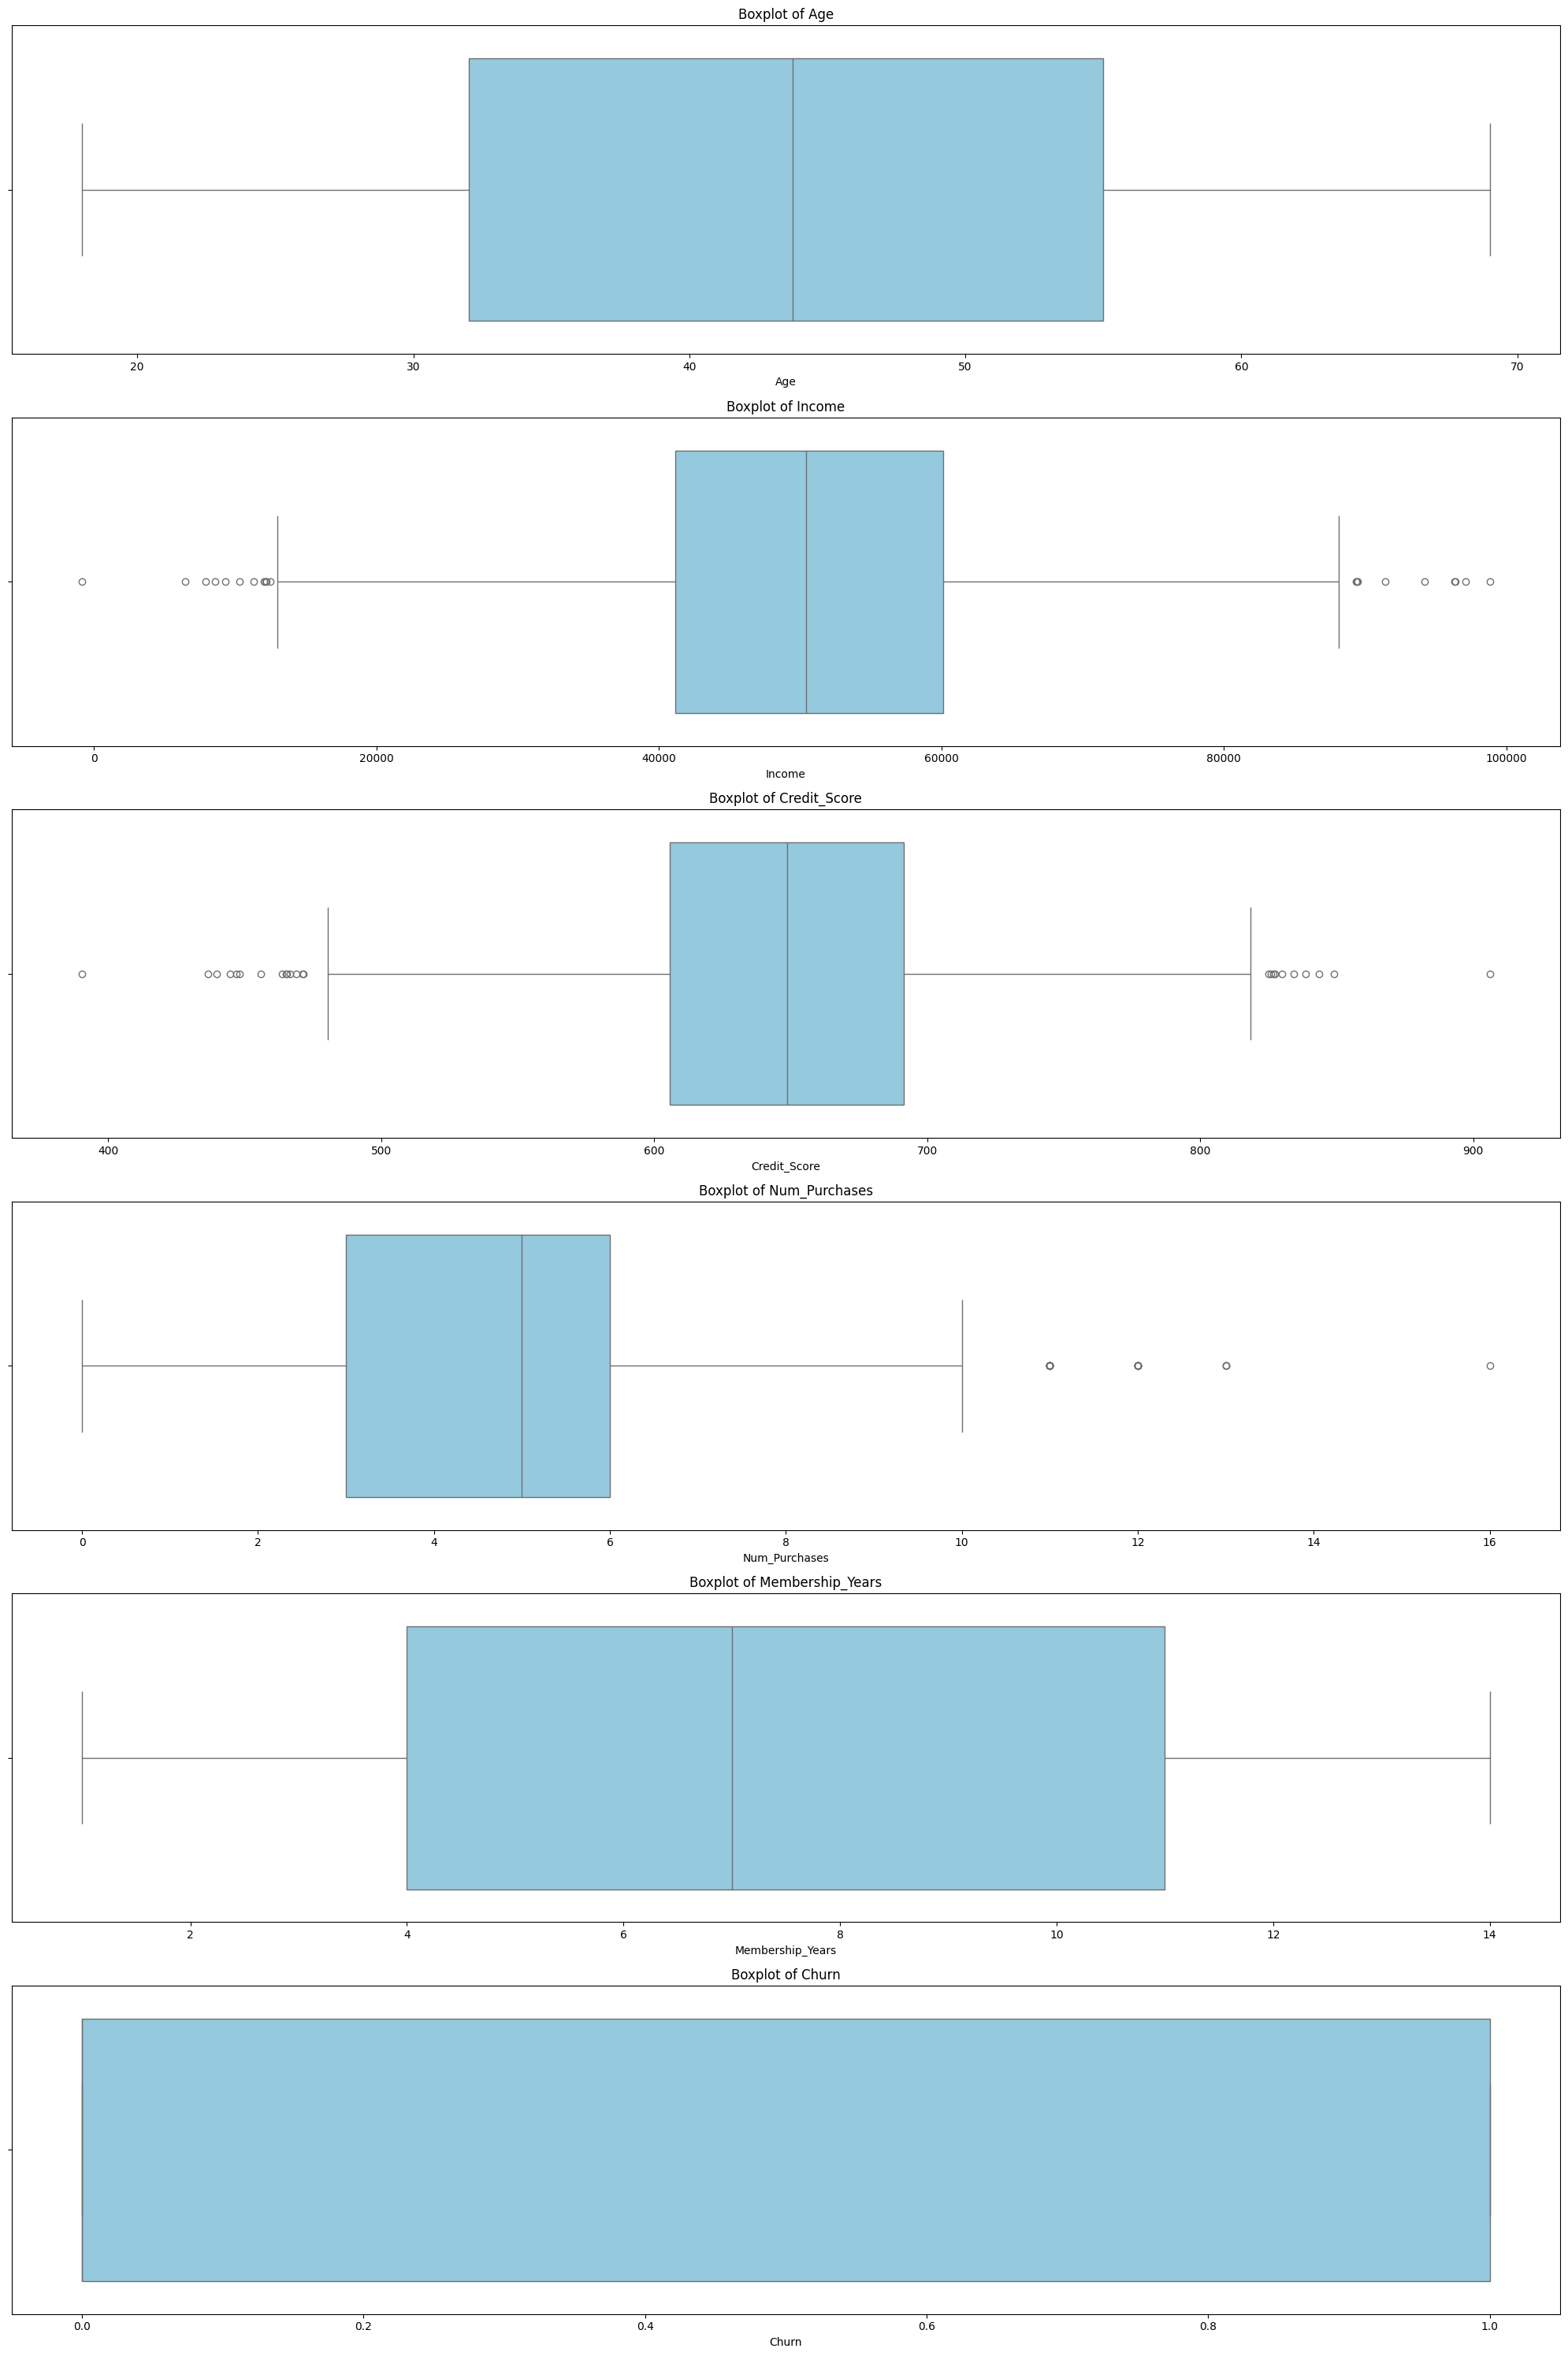

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In [ ]:
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head(10)

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.000000,70201.189680,0,1,687.761776,9,12,0,0
1,69.000000,51901.897395,1,2,712.617115,3,14,2,0
2,46.000000,38605.409293,1,1,782.299643,5,8,1,0
3,32.000000,49949.736955,0,2,697.749518,7,1,2,0
4,43.750175,48965.290095,2,1,663.155216,4,4,0,1
5,25.000000,11326.768555,0,0,697.061084,1,4,0,1
6,38.000000,41579.497114,2,0,687.615220,5,6,2,1
7,56.000000,54713.055994,0,1,714.708713,7,12,2,0
8,36.000000,43636.766522,1,0,540.098369,3,12,0,0
9,40.000000,40306.859573,1,0,648.786794,3,2,1,0


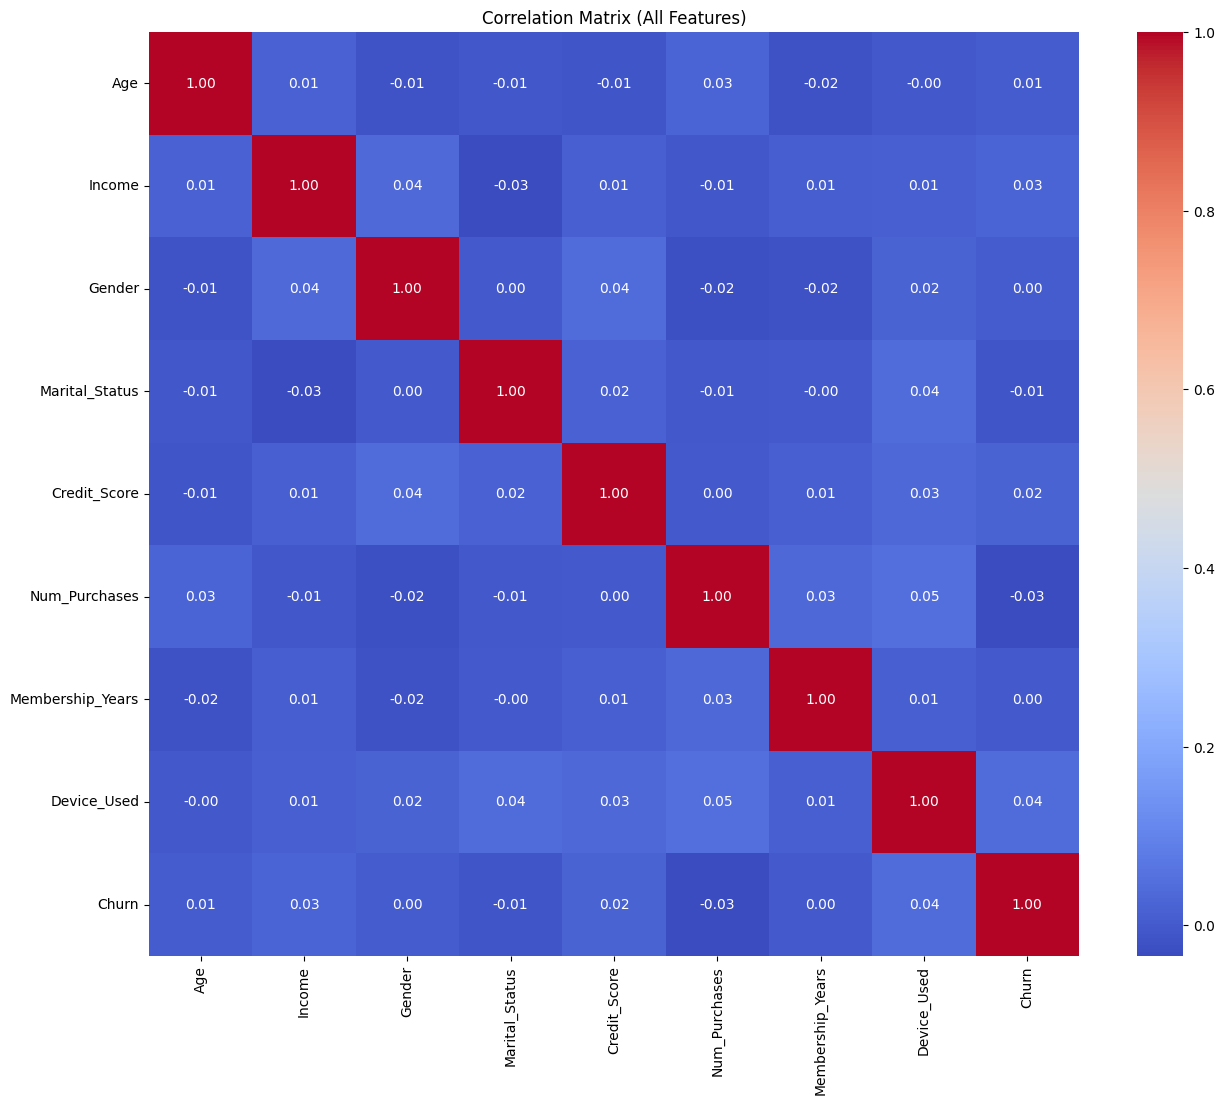

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (All Features)")
plt.show()

In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 0.83670716  1.32341571 -1.29802794 ...  1.73518055  1.16058663
  -1.18447719]
 [ 1.72465401  0.09752236 -0.08188683 ... -0.91980499  1.66394934
   1.23941883]
 [ 0.15367112 -0.79322664 -0.08188683 ... -0.03480981  0.1538612
   0.02747082]
 ...
 [-1.07579374  0.14429729  1.13425427 ... -1.36230258 -1.10454558
  -1.18447719]
 [-1.41731176  0.85356922 -1.29802794 ... -0.03480981 -0.09782015
   1.23941883]
 [-0.59766851 -0.18282933  1.13425427 ... -0.03480981 -0.85286422
   0.02747082]]


In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"Original Data Shape: {X.shape}")
print(f"Balanced Data Shape: {X_resampled.shape}")

Original Data Shape: (1500, 8)
Balanced Data Shape: (1514, 8)


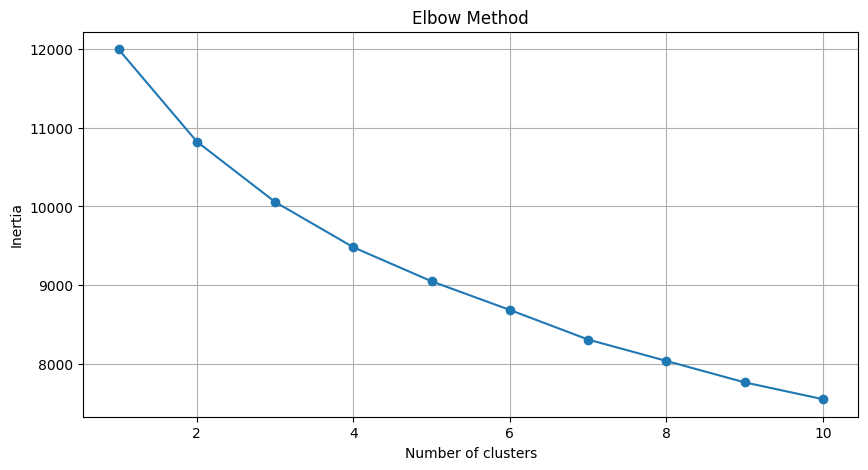

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

Model Training & Testing

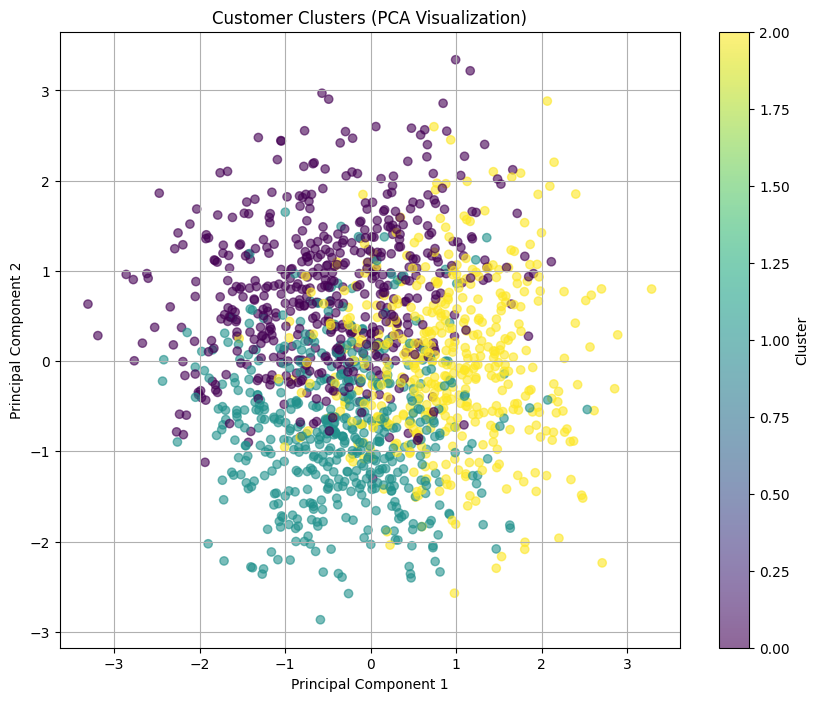

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('Customer Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=6)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.5133
              precision    recall  f1-score   support

           0       0.52      0.69      0.60       156
           1       0.49      0.32      0.39       144

    accuracy                           0.51       300
   macro avg       0.51      0.51      0.49       300
weighted avg       0.51      0.51      0.50       300



In [ ]:
nn_model = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=42)
nn_model.fit(X_train, y_train)

y_pred_nn = nn_model.predict(X_test)
print(f"Neural Network Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(classification_report(y_test, y_pred_nn))

Neural Network Accuracy: 0.4833
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       156
           1       0.46      0.51      0.49       144

    accuracy                           0.48       300
   macro avg       0.48      0.48      0.48       300
weighted avg       0.49      0.48      0.48       300



In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5267

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.55      0.52      0.53       156
           1       0.51      0.53      0.52       144

    accuracy                           0.53       300
   macro avg       0.53      0.53      0.53       300
weighted avg       0.53      0.53      0.53       300



Model Evaluation

/tmp/ipython-input-603714364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='viridis')


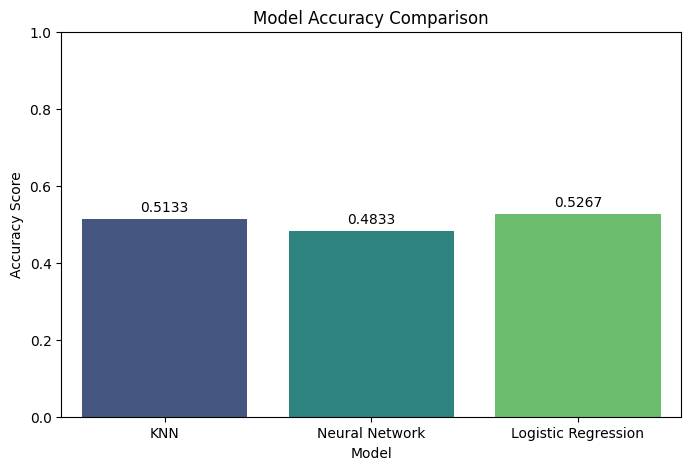

In [ ]:
models_list = [
    ("KNN", knn_model),
    ("Neural Network", nn_model),
    ("Logistic Regression", lr_model)
]

accuracy_results = []

for name, model in models_list:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results.append({"Model": name, "Accuracy": acc})


acc_df = pd.DataFrame(accuracy_results)


plt.figure(figsize=(8, 5))
plot = sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='viridis')
plt.ylim(0, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')

for index, row in acc_df.iterrows():
    plot.text(index, row['Accuracy'] + 0.02, f"{row['Accuracy']:.4f}", ha='center')

plt.show()

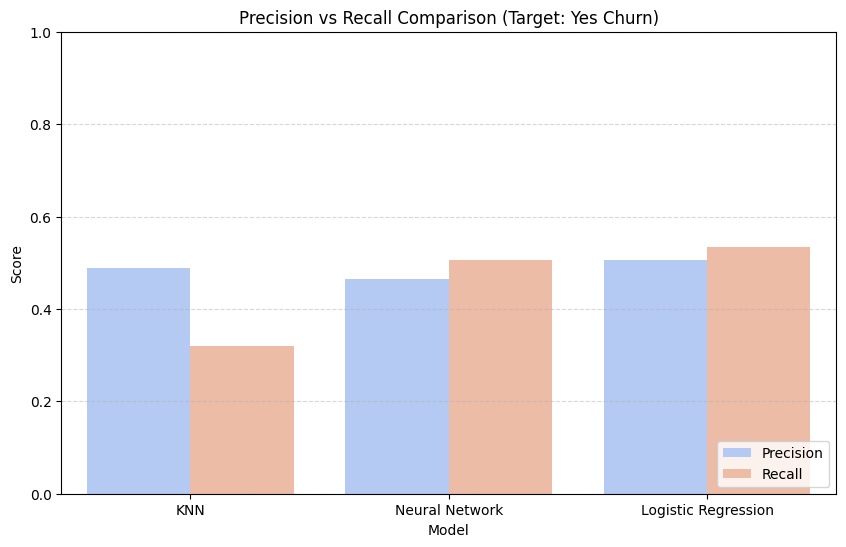

In [ ]:
pr_results = []

for name, model in models_list:
    y_pred = model.predict(X_test)

    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    pr_results.append({"Model": name, "Metric": "Precision", "Score": prec})
    pr_results.append({"Model": name, "Metric": "Recall", "Score": rec})

pr_df = pd.DataFrame(pr_results)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=pr_df, palette='coolwarm')

plt.title('Precision vs Recall Comparison (Target: Yes Churn)')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

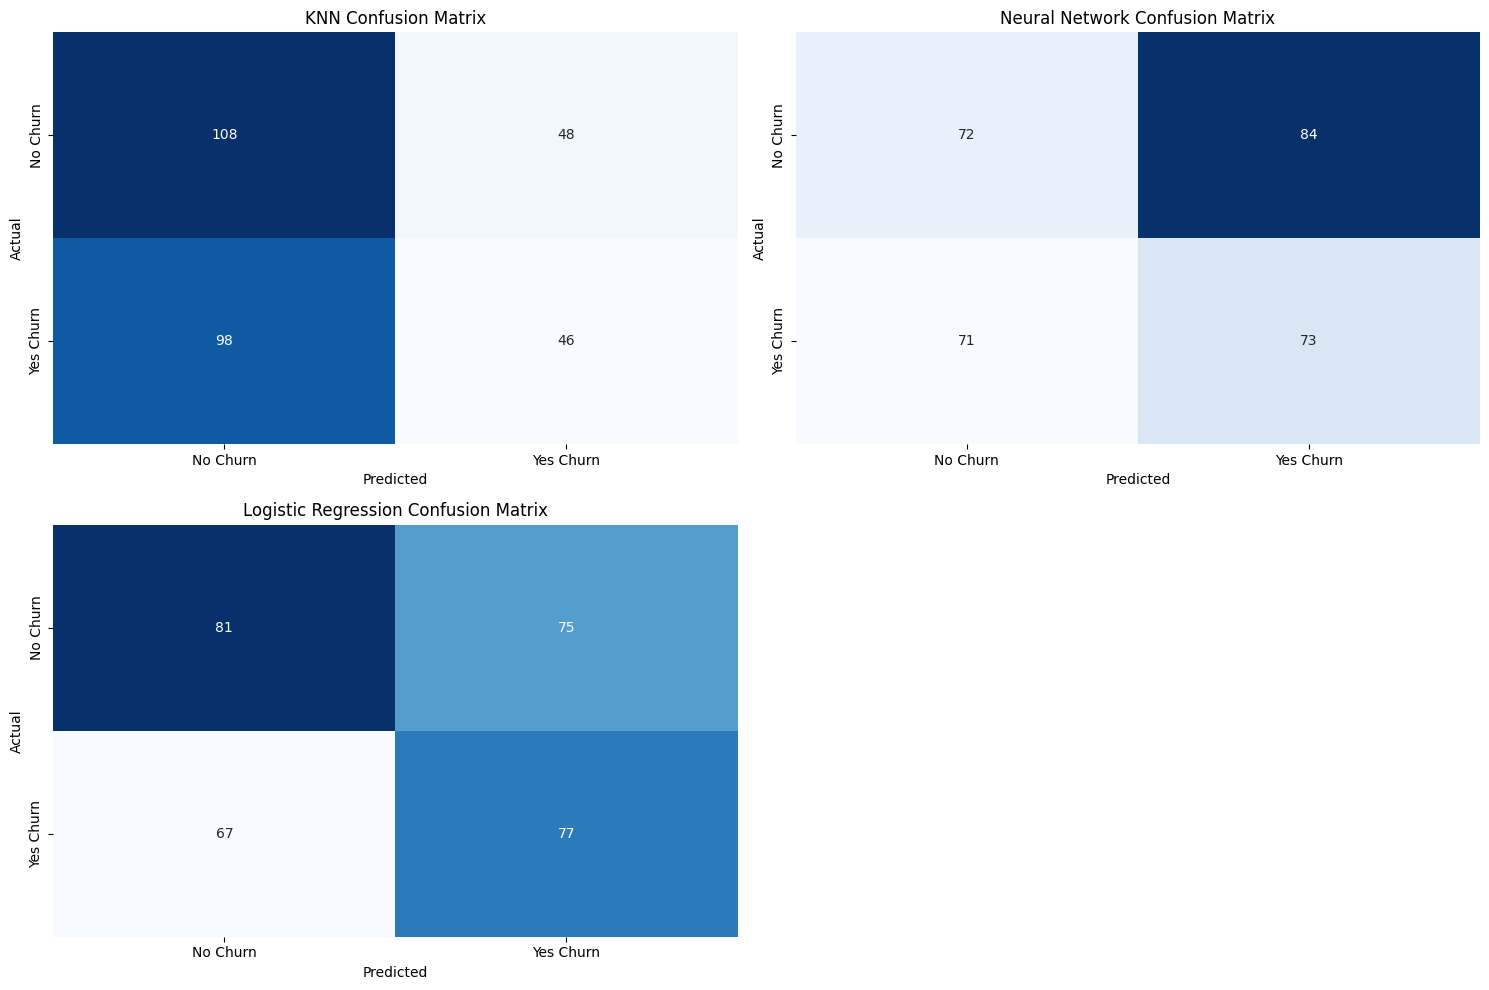

In [ ]:
model_list = [
    ("KNN", knn_model),
    ("Neural Network", nn_model),
    ("Logistic Regression", lr_model)
]

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(model_list):
    plt.subplot(2, 2, i+1)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks([0.5, 1.5], ['No Churn', 'Yes Churn'])
    plt.yticks([0.5, 1.5], ['No Churn', 'Yes Churn'])

plt.tight_layout()
plt.show()

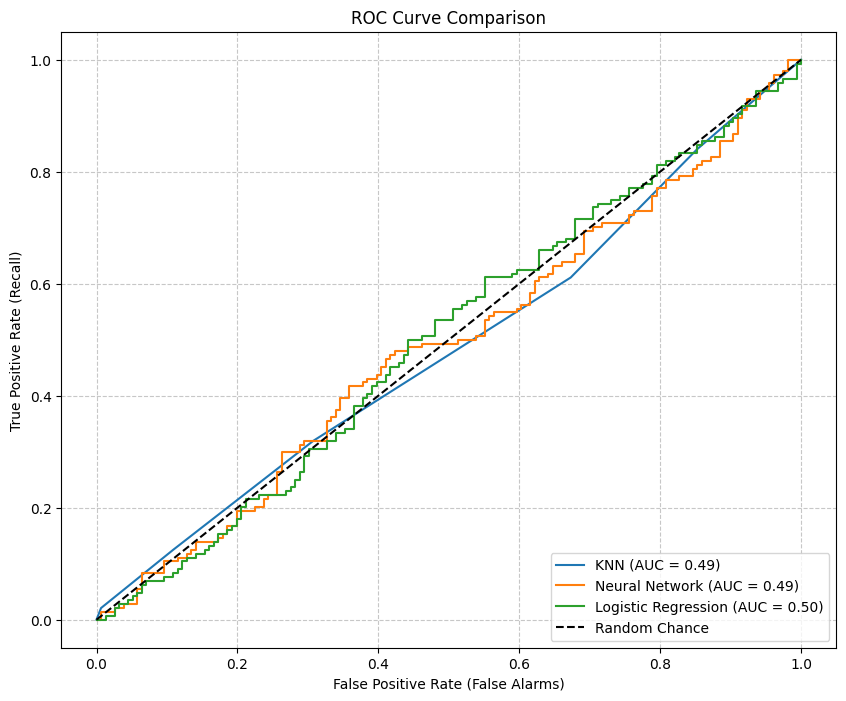

In [ ]:
plt.figure(figsize=(10, 8))
for name, model in model_list:
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
models_list = [
    ("KNN", knn_model),
    ("Neural Network", nn_model),
    ("Logistic Regression", lr_model)
]

print("Cross-Validation Accuracy:")
print("-" * 30)

for name, model in models_list:
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross-Validation Accuracy:
------------------------------
KNN: 0.4833 (+/- 0.0371)
Neural Network: 0.4958 (+/- 0.0409)
Logistic Regression: 0.5000 (+/- 0.0386)
